In [2]:
pip install langgraph

  Using cached langgraph_checkpoint-4.1.1-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.2-py3-none-any.whl.metadata (3.6 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached xxhash-3.8.1-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_protocol-0.0.18-py3-none-any.whl.metadata (2.4 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached uuid_utils-0.17.0-cp312-cp312-win_amd64.whl.metadata (6.5 kB)
  Using cached ormsgpack-1.12.2-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached orjson-3.11.9-cp312-cp312-win_amd64.whl.metadata (43 kB)
  Using cached websockets-15.0.1-cp312-cp312-win_amd64.whl.metadata (7.


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
! pip install langchain langchain_groq langchain-community langgraph python-dotenv faiss-cpu pypdf

Defaulting to user installation because normal site-packages is not writeable


In [5]:
pip install langchain_groq

  Using cached langchain_groq-1.1.3-py3-none-any.whl.metadata (2.9 kB)
  Using cached groq-0.37.1-py3-none-any.whl.metadata (16 kB)
Using cached langchain_groq-1.1.3-py3-none-any.whl (20 kB)
Using cached groq-0.37.1-py3-none-any.whl (137 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
pip install python-dotenv

  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

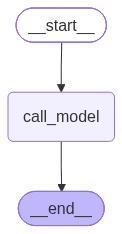

In [6]:
graph = builder.compile()
graph

In [7]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]})

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='f7584876-c014-481b-88fb-58355fee04f9'),
  AIMessage(content="Hello Nitish! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 43, 'total_tokens': 70, 'completion_time': 0.040802153, 'completion_tokens_details': None, 'prompt_time': 0.001963733, 'prompt_tokens_details': None, 'queue_time': 0.050184227, 'total_time': 0.042765886}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019faf64-d8a0-78e2-9da4-33fbea1c936e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 27, 'total_tokens': 70})]}

In [8]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='9e36ed36-4b74-4104-9557-e1e6c4022dd7'),
  AIMessage(content="I don't know your name. I'm a large language model, I don't have the ability to know your personal information or retain any information about our previous conversations. Each time you interact with me, it's a new conversation. If you'd like to share your name with me, I'd be happy to chat with you!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 40, 'total_tokens': 108, 'completion_time': 0.139282494, 'completion_tokens_details': None, 'prompt_time': 0.001742255, 'prompt_tokens_details': None, 'queue_time': 0.057272494, 'total_time': 0.141024749}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019faf64-f4ee-7df2-9154-2431003c46de-

In [9]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [10]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [11]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [12]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [13]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='ad688560-1186-4a6d-a13e-c8124aaf77a8'),
  AIMessage(content="Hello Nitish! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 43, 'total_tokens': 70, 'completion_time': 0.03532171, 'completion_tokens_details': None, 'prompt_time': 0.004967757, 'prompt_tokens_details': None, 'queue_time': 0.050481373, 'total_time': 0.040289467}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019faf65-982b-73d3-b040-2ecf7a184791-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 27, 'total_tokens': 70})]}

In [14]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='a0d30e2d-3728-4338-ad54-6e55bbcafa55'),
  AIMessage(content="I don't know your name. I'm a large language model, I don't have the ability to know your personal information or recall previous conversations. Each time you interact with me, it's a new conversation and I don't retain any information about you. If you'd like to share your name with me, I'd be happy to chat with you and use it in our conversation!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 40, 'total_tokens': 119, 'completion_time': 0.188120018, 'completion_tokens_details': None, 'prompt_time': 0.001037601, 'prompt_tokens_details': None, 'queue_time': 0.051098828, 'total_time': 0.189157619}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'},

In [15]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Nitish.
- AIMessage : Hello Nitish! It's nice to meet you. Is there something I can help you with or would you like to chat?
